# Run only in case of local runtime

In [ ]:
import sys
print(sys.executable)

!{sys.executable} -m pip install tensorflow-macos tensorflow-metal
#restart session after running this cell

/Library/Frameworks/Python.framework/Versions/3.10/bin/python3


In [ ]:
import os

BASE_PATH = "/Users/rahafal-harbi/Documents/ml_datasets/prescription/Doctor Handwritten Prescription BD dataset"

train_dir = os.path.join(BASE_PATH, "Training")
val_dir   = os.path.join(BASE_PATH, "Validation")
test_dir  = os.path.join(BASE_PATH, "Testing")

train_labels_path = os.path.join(train_dir, "training_labels.csv")
val_labels_path   = os.path.join(val_dir,   "validation_labels.csv")
test_labels_path  = os.path.join(test_dir,  "testing_labels.csv")

import pandas as pd
df_train = pd.read_csv(train_labels_path)
df_val   = pd.read_csv(val_labels_path)
df_test  = pd.read_csv(test_labels_path)

# Handwritten Prescription Medicine Classification  
### CNN vs EfficientNetB0 vs ResNet50


The goal of this notebook is to evaluate the effectiveness of a custom CNN against transfer learning models using EfficientNetB0 and ResNet50.

In [ ]:
import os
import numpy as np
import pandas as pd
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
from tensorflow.keras.applications.efficientnet import EfficientNetB0, preprocess_input as eff_preprocess
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input as resnet_preprocess
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization,Input, Resizing, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
from google.colab import files
import zipfile

zip_path = "content/Doctor Handwritten Prescription BD dataset/"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction DONE")

In [ ]:
BASE_PATH = "/Users/rahafal-harbi/Downloads/Doctor Handwritten Prescription BD dataset/"

train_dir = os.path.join(BASE_PATH, "Training")
test_dir  = os.path.join(BASE_PATH, "Testing")
val_dir   = os.path.join(BASE_PATH, "Validation")

## Dataset Description

The dataset contains handwritten images of medicine names collected from prescriptions.
Each image is labeled with the corresponding medicine name.

**Dataset splits:**
- Training set
- Validation set
- Test set

All images are RGB and resized according to model requirements.

In [ ]:
IMG_SIZE = 64
IMAGE_COL = 'IMAGE'
LABEL_COL = 'MEDICINE_NAME'

In [ ]:
train_labels_path = os.path.join(train_dir, "training_labels.csv")
val_labels_path   = os.path.join(val_dir,   "validation_labels.csv")
test_labels_path  = os.path.join(test_dir,  "testing_labels.csv")

df_train = pd.read_csv(train_labels_path)
df_val   = pd.read_csv(val_labels_path)
df_test  = pd.read_csv(test_labels_path)


all_labels_df = pd.concat([df_train, df_val, df_test], ignore_index=True)

label_encoder = LabelEncoder()
label_encoder.fit(all_labels_df[LABEL_COL])

num_classes = len(label_encoder.classes_)
print("Number of classes:", num_classes)
print("First 10 labels:", label_encoder.classes_[:10])


Number of classes: 78
First 10 labels: ['Ace' 'Aceta' 'Alatrol' 'Amodis' 'Atrizin' 'Axodin' 'Az' 'Azithrocin'
 'Azyth' 'Bacaid']


## Data Preprocessing

Images were normalized and resized before training.
- For the CNN model, images were resized to **64×64**.
- For transfer learning models, images were resized to **224×224**.

Label encoding was applied to convert medicine names into numerical class representations.

In [ ]:
def load_split(image_folder, labels_df, label_encoder, img_size=64):
    images = []
    labels_enc = []

    for _, row in labels_df.iterrows():
        img_name = row[IMAGE_COL]
        label    = row[LABEL_COL]

        img_path = os.path.join(image_folder, img_name)
        if not os.path.exists(img_path):
            continue

        # Load image and resize
        img = load_img(img_path, target_size=(img_size, img_size), color_mode="rgb")
        img = img_to_array(img)
        img = img.astype("float32") / 255.0

        images.append(img)

        class_idx = label_encoder.transform([label])[0]
        labels_enc.append(class_idx)

    X = np.array(images, dtype="float32")
    y = to_categorical(np.array(labels_enc), num_classes=num_classes)

    print(f"Loaded {X.shape[0]} images from {image_folder}")
    return X, y

In [ ]:
train_img_dir = os.path.join(BASE_PATH, "Training",   "training_words")
val_img_dir   = os.path.join(BASE_PATH, "Validation", "validation_words")
test_img_dir  = os.path.join(BASE_PATH, "Testing",    "testing_words")

X_train, y_train = load_split(train_img_dir, df_train, label_encoder, IMG_SIZE)
X_val,   y_val   = load_split(val_img_dir,   df_val,   label_encoder, IMG_SIZE)
X_test,  y_test  = load_split(test_img_dir,  df_test,  label_encoder, IMG_SIZE)

print("\n--- Split Summary ---")
print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape,   y_val.shape)
print("Test: ", X_test.shape,  y_test.shape)

Loaded 3120 images from /Users/rahafal-harbi/Documents/ml_datasets/prescription/Doctor Handwritten Prescription BD dataset/Training/training_words
Loaded 780 images from /Users/rahafal-harbi/Documents/ml_datasets/prescription/Doctor Handwritten Prescription BD dataset/Validation/validation_words
Loaded 780 images from /Users/rahafal-harbi/Documents/ml_datasets/prescription/Doctor Handwritten Prescription BD dataset/Testing/testing_words

--- Split Summary ---
Train: (3120, 64, 64, 3) (3120, 78)
Val:   (780, 64, 64, 3) (780, 78)
Test:  (780, 64, 64, 3) (780, 78)


# Examine Data

In [ ]:
import matplotlib.pyplot as plt

def show_sample_images(X, y, label_encoder, num_samples=5):
    plt.figure(figsize=(15, 5))

    for i in range(num_samples):
        plt.subplot(1, num_samples, i + 1)

        plt.imshow(X[i])
        plt.axis('off')

        class_idx = np.argmax(y[i])
        label = label_encoder.classes_[class_idx]

        plt.title(label)

    plt.show()

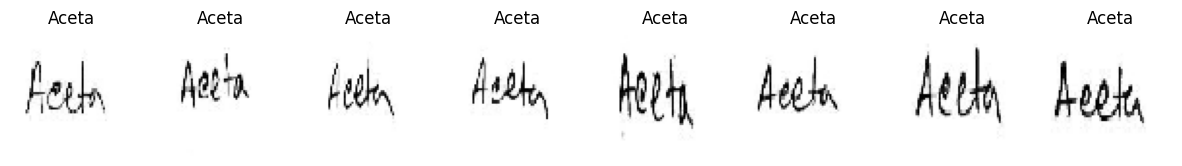

In [ ]:
show_sample_images(X_train, y_train, label_encoder, num_samples=8)

## Data Augmentation

To improve generalization and reduce overfitting, data augmentation was applied to the training set.
The following transformations were used:
- Rotation
- Width and height shifting
- Shearing
- Zooming

Augmentation was applied **only to training data** and kept identical across all models to ensure fair comparison.

In [ ]:
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=False,
    fill_mode="nearest",
)

datagen.fit(X_train)

## Callback Functions

Callbacks were used to control and optimize the training process dynamically.
They help prevent overfitting, stabilize learning, and ensure that the best-performing model is retained.

In [ ]:
def make_callbacks(ckpt_path):
    early = EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True,
        verbose=1
    )
    reduceLR = ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
    ckpt = ModelCheckpoint(
        ckpt_path,
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )
    return [early, reduceLR, ckpt]

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

def show_random_predictions_auto(
    model,
    X_test_raw,
    y_test,
    label_encoder,
    num_samples=12,
    title="",
    preprocess="none"
):
    in_shape = model.input_shape
    target_h, target_w = in_shape[1], in_shape[2]

    idx_to_class = {i: c for i, c in enumerate(label_encoder.classes_)}
    indices = np.random.choice(len(X_test_raw), num_samples, replace=False)

    plt.figure(figsize=(15, 8))

    for i, idx in enumerate(indices):
        img_raw = X_test_raw[idx]
        true_class = int(np.argmax(y_test[idx]))

        img_model = img_raw

        if (img_raw.shape[0] != target_h) or (img_raw.shape[1] != target_w):
            img_model = tf.image.resize(img_model, (target_h, target_w)).numpy()

        if preprocess == "eff":
            img_model = eff_preprocess(img_model * 255.0)
        elif preprocess == "res":
            img_model = resnet_preprocess(img_model * 255.0)

        pred = model.predict(img_model[np.newaxis, ...], verbose=0)
        pred_class = int(np.argmax(pred, axis=1)[0])

        pred_label = idx_to_class[pred_class]
        true_label = idx_to_class[true_class]
        color = "green" if pred_class == true_class else "red"

        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(img_raw)
        plt.title(f"Pred: {pred_label}\nTrue: {true_label}", color=color, fontsize=9)
        plt.axis("off")

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

## Convolutional Neural Network (CNN)

A custom CNN was designed as a baseline model.
The architecture consists of:
- Multiple convolutional layers with ReLU activation
- Batch normalization
- Max pooling layers
- Fully connected layers with dropout

The CNN operates on **64×64** input images.

In [ ]:
model = Sequential([
    Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(256, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(512, (3, 3), activation='relu'),
    BatchNormalization(),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax'),
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 62, 62, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 62, 62, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 31, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 29, 29, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 29, 29, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 4, 4, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 78)             │        20,046 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,901,006 (22.51 MB)

 Trainable params: 5,899,086 (22.50 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [ ]:
callbacks_cnn = make_callbacks("cnn_best.keras")


history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_val, y_val),
    epochs=50,
    callbacks=callbacks_cnn,
)

Epoch 1/50


2025-12-13 17:44:16.692192: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


97/98 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.0348 - loss: 20.9943
Epoch 1: val_accuracy improved from None to 0.01282, saving model to cnn_best.keras
98/98 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.0304 - loss: 29.6066 - val_accuracy: 0.0128 - val_loss: 44.0322 - learning_rate: 0.0010
Epoch 2/50
97/98 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.0270 - loss: 47.3987
Epoch 2: val_accuracy improved from 0.01282 to 0.01667, saving model to cnn_best.keras
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.0295 - loss: 46.7600 - val_accuracy: 0.0167 - val_loss: 52.9318 - learning_rate: 0.0010
Epoch 3/50
97/98 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.0313 - loss: 48.4715
Epoch 3: val_accuracy improved from 0.01667 to 0.03590, saving model to cnn_best.keras
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.0391 - loss: 45.8065 - val_accuracy: 0.0359 - val_loss: 28.5177 - learning_rate: 0.0010
Epoch 4/50
97/98 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.0499

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_acc*100:.2f}%")

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6385 - loss: 11.7932
Test accuracy: 63.85%


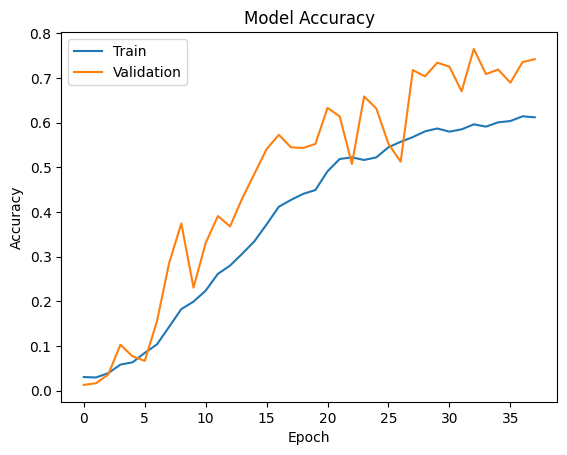

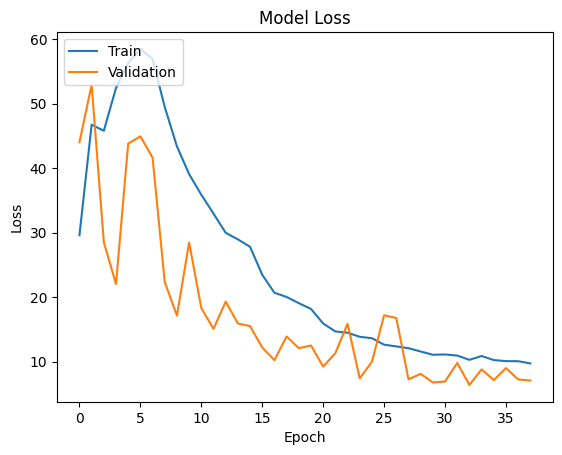

In [ ]:
# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

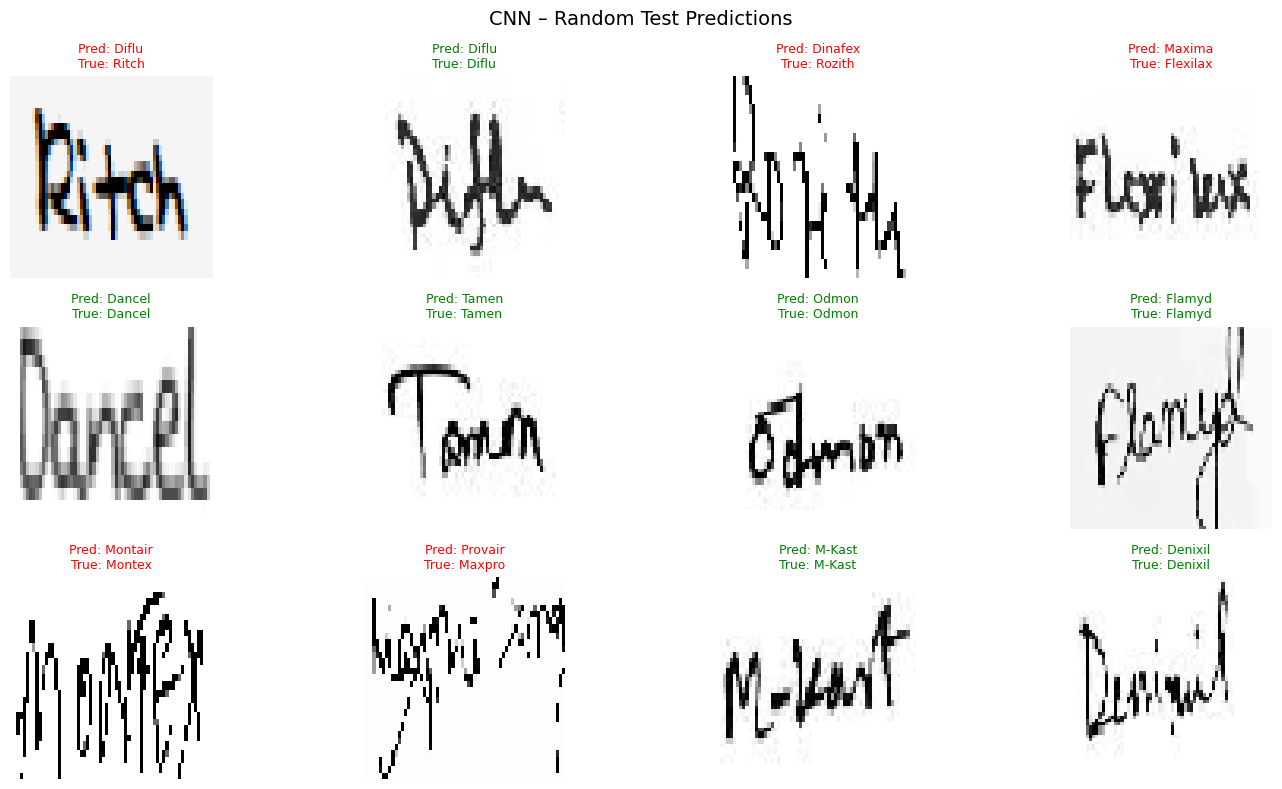

In [ ]:
show_random_predictions(
    model=model,
    X_test=X_test,
    y_test=y_test,
    label_encoder=label_encoder,
    title="CNN (64×64) – Random Test Predictions"
)


In [ ]:
import gc, tensorflow as tf
gc.collect()
tf.keras.backend.clear_session()

## EfficientNetB0 (Transfer Learning)

EfficientNetB0 was used as a transfer learning model pretrained on ImageNet.
The base network was initially frozen, and a custom classification head was added.

Training was performed in two stages:
1. Training only the classification head
2. Fine-tuning the upper layers of the backbone

Input image size: **224×224**

In [ ]:
def eff_preprocess_01(x):
    x = x * 255.0
    return eff_preprocess(x)

In [ ]:
TL_IMG_SIZE = 224

X_train_tl = tf.image.resize(X_train, (TL_IMG_SIZE, TL_IMG_SIZE))
X_val_tl   = tf.image.resize(X_val, (TL_IMG_SIZE, TL_IMG_SIZE))
X_test_tl  = tf.image.resize(X_test, (TL_IMG_SIZE, TL_IMG_SIZE))

X_train_eff = eff_preprocess_01(X_train_tl.numpy().copy())
X_val_eff   = eff_preprocess_01(X_val_tl.numpy().copy())
X_test_eff  = eff_preprocess_01(X_test_tl.numpy().copy())

print("Eff preprocessed shapes:")
print("X_train_eff:", X_train_eff.shape)
print("X_val_eff:  ", X_val_eff.shape)
print("X_test_eff: ", X_test_eff.shape)

2025-12-13 22:36:38.478005: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2025-12-13 22:36:38.478044: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2025-12-13 22:36:38.478053: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.00 GB
2025-12-13 22:36:38.478092: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-12-13 22:36:38.478106: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Eff preprocessed shapes:
X_train_eff: (3120, 224, 224, 3)
X_val_eff:   (780, 224, 224, 3)
X_test_eff:  (780, 224, 224, 3)


Data Augmentation

In [ ]:
datagen.fit(X_train_eff)

eff_model_checkpoint = ModelCheckpoint(
    "efficientnet_b0_best.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

EfficientNetB0 Model

In [ ]:
eff_base = EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(TL_IMG_SIZE, TL_IMG_SIZE, 3),
    pooling='avg'
)

eff_base.trainable = False

eff_input = Input(shape=(TL_IMG_SIZE, TL_IMG_SIZE, 3))
x = eff_base(eff_input, training=False)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
eff_output = Dense(num_classes, activation='softmax')(x)

eff_model = Model(inputs=eff_input, outputs=eff_output, name="EfficientNetB0_drug_classifier")

eff_model.summary()

Model: "EfficientNetB0_drug_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 78)             │        20,046 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,397,553 (16.78 MB)

 Trainable params: 347,982 (1.33 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
# Compile - head only
eff_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

EPOCHS_STAGE1 = 15
BATCH_SIZE = 32

callbacks_eff1 = make_callbacks("efficientnet_b0_best.keras")

history_eff_stage1 = eff_model.fit(
    datagen.flow(X_train_eff, y_train, batch_size=BATCH_SIZE),
    validation_data=(X_val_eff, y_val),
    epochs=EPOCHS_STAGE1,
    callbacks=callbacks_eff1,
    verbose=1
)

Epoch 1/15
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.0342 - loss: 4.6463
Epoch 1: val_accuracy improved from None to 0.20897, saving model to efficientnet_b0_best.keras
98/98 ━━━━━━━━━━━━━━━━━━━━ 17s 139ms/step - accuracy: 0.0519 - loss: 4.4876 - val_accuracy: 0.2090 - val_loss: 3.5038 - learning_rate: 0.0010
Epoch 2/15
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.1174 - loss: 3.9060
Epoch 2: val_accuracy improved from 0.20897 to 0.33590, saving model to efficientnet_b0_best.keras
98/98 ━━━━━━━━━━━━━━━━━━━━ 12s 120ms/step - accuracy: 0.1269 - loss: 3.8082 - val_accuracy: 0.3359 - val_loss: 2.8590 - learning_rate: 0.0010
Epoch 3/15
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.1770 - loss: 3.4554
Epoch 3: val_accuracy improved from 0.33590 to 0.40769, saving model to efficientnet_b0_best.keras
98/98 ━━━━━━━━━━━━━━━━━━━━ 12s 118ms/step - accuracy: 0.1926 - loss: 3.3597 - val_accuracy: 0.4077 - val_loss: 2.5301 - learning_rate: 0.0010
Epoch 4/15
98/98 ━━━━━━━━

In [ ]:
# Stage 2: fine-tuning

eff_base.trainable = True

for layer in eff_base.layers[:-50]:
    layer.trainable = False

eff_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

EPOCHS_STAGE2 = 20

callbacks_eff2 = make_callbacks("efficientnet_b0_best.keras")

history_eff_stage2 = eff_model.fit(
    datagen.flow(X_train_eff, y_train, batch_size=BATCH_SIZE),
    validation_data=(X_val_eff, y_val),
    epochs=EPOCHS_STAGE2,
    callbacks=callbacks_eff2,
    verbose=1
)

Epoch 1/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.3521 - loss: 2.6524
Epoch 1: val_accuracy improved from None to 0.62692, saving model to efficientnet_b0_best.keras
98/98 ━━━━━━━━━━━━━━━━━━━━ 25s 193ms/step - accuracy: 0.4112 - loss: 2.2925 - val_accuracy: 0.6269 - val_loss: 1.4015 - learning_rate: 1.0000e-04
Epoch 2/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.5543 - loss: 1.6175
Epoch 2: val_accuracy improved from 0.62692 to 0.67308, saving model to efficientnet_b0_best.keras
98/98 ━━━━━━━━━━━━━━━━━━━━ 15s 153ms/step - accuracy: 0.5785 - loss: 1.5599 - val_accuracy: 0.6731 - val_loss: 1.2277 - learning_rate: 1.0000e-04
Epoch 3/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.6373 - loss: 1.3116
Epoch 3: val_accuracy improved from 0.67308 to 0.71282, saving model to efficientnet_b0_best.keras
98/98 ━━━━━━━━━━━━━━━━━━━━ 15s 155ms/step - accuracy: 0.6356 - loss: 1.3045 - val_accuracy: 0.7128 - val_loss: 1.0876 - learning_rate: 1.0000e-04
Epoch 4/20

In [ ]:
eff_test_loss, eff_test_acc = eff_model.evaluate(X_test_eff, y_test, verbose=0)
print(f"EfficientNetB0 Test Accuracy: {eff_test_acc * 100:.2f}%")
print(f"EfficientNetB0 Test Loss: {eff_test_loss:.4f}")

EfficientNetB0 Test Accuracy: 69.62%
EfficientNetB0 Test Loss: 1.4876


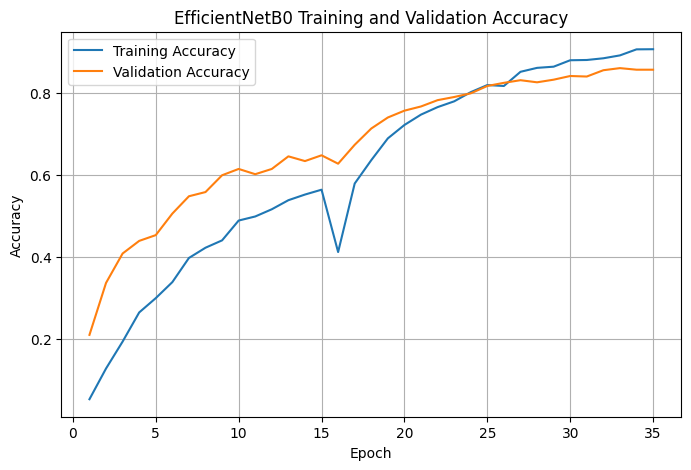

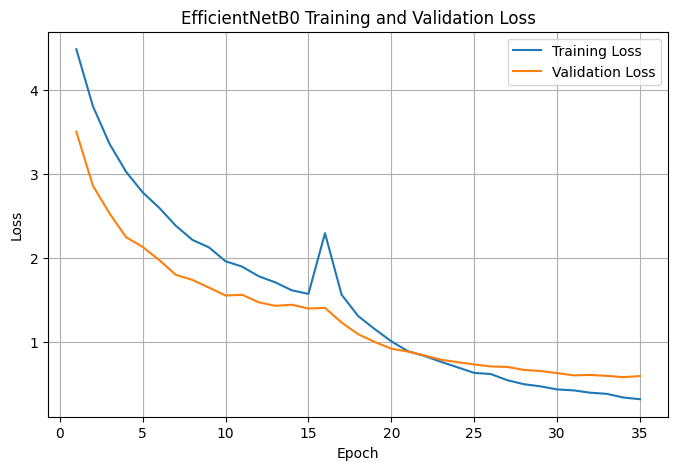

In [ ]:
acc = history_eff_stage1.history['accuracy'] + history_eff_stage2.history['accuracy']
val_acc = history_eff_stage1.history['val_accuracy'] + history_eff_stage2.history['val_accuracy']

loss = history_eff_stage1.history['loss'] + history_eff_stage2.history['loss']
val_loss = history_eff_stage1.history['val_loss'] + history_eff_stage2.history['val_loss']

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')

plt.title('EfficientNetB0 Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')

plt.title('EfficientNetB0 Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()



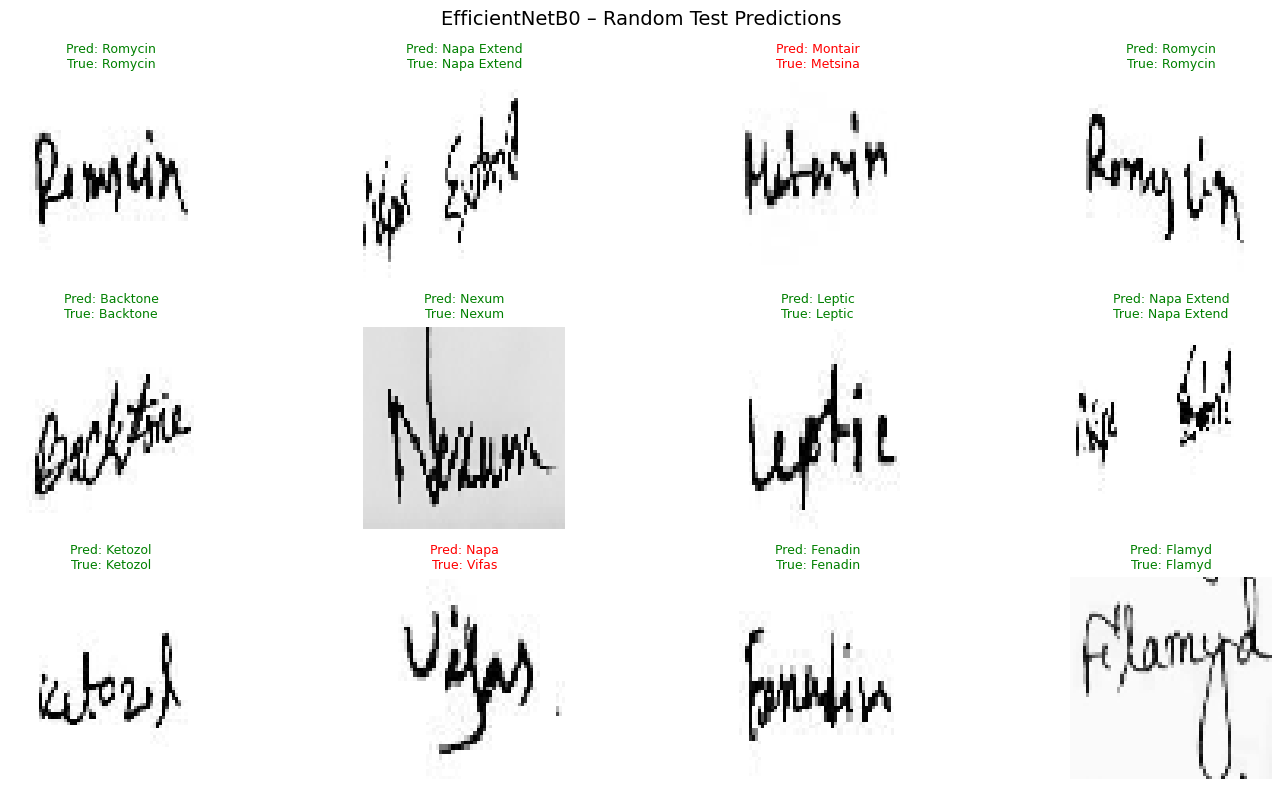

In [ ]:
show_random_predictions_auto(
    model=eff_model,
    X_test_raw=X_test,
    y_test=y_test,
    label_encoder=label_encoder,
    title="EfficientNetB0 – Random Test Predictions",
    preprocess="eff"
)

## ResNet50 (Transfer Learning)

ResNet50, pretrained on ImageNet, was used as another transfer learning approach.
Similar to EfficientNet, a custom classification head was added.

The model was trained in two stages:
1. Feature extraction with frozen backbone
2. Fine-tuning selected layers

Input image size: **224×224**

In [ ]:
def resnet_preprocess_01(x):
    """
    x is in [0,1] → convert to [0,255] then apply ResNet50 preprocessing.
    """
    x = x * 255.0
    return resnet_preprocess(x)

X_train_res = resnet_preprocess_01(X_train_tl)
X_val_res   = resnet_preprocess_01(X_val_tl)
X_test_res  = resnet_preprocess_01(X_test_tl)

print("ResNet preprocessed shapes:")
print("X_train_res:", X_train_res.shape)
print("X_val_res:  ", X_val_res.shape)
print("X_test_res: ", X_test_res.shape)

ResNet preprocessed shapes:
X_train_res: (3120, 224, 224, 3)
X_val_res:   (780, 224, 224, 3)
X_test_res:  (780, 224, 224, 3)


In [ ]:
res_base = ResNet50(
    include_top=False,
    weights='imagenet',
    input_shape=(TL_IMG_SIZE, TL_IMG_SIZE, 3),
    pooling='avg'
)

res_base.trainable = False

res_input = Input(shape=(TL_IMG_SIZE, TL_IMG_SIZE, 3))
x = res_base(res_input, training=False)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
res_output = Dense(num_classes, activation='softmax')(x)

res_model = Model(inputs=res_input, outputs=res_output, name="ResNet50_drug_classifier")

res_model.summary()

Model: "ResNet50_drug_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 2048)           │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 78)             │        20,046 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,132,302 (92.06 MB)

 Trainable params: 544,590 (2.08 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
# Compile - head only (Stage 1)
res_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

RES_EPOCHS_STAGE1 = 20
RES_BATCH_SIZE = 32

callbacks_res1 = make_callbacks("resnet50_best.keras")

history_res_stage1 = res_model.fit(
    datagen.flow(X_train_res, y_train, batch_size=RES_BATCH_SIZE),
    validation_data=(X_val_res, y_val),
    epochs=RES_EPOCHS_STAGE1,
    callbacks=callbacks_res1,
    verbose=1
)

Epoch 1/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.0234 - loss: 7.4582
Epoch 1: val_accuracy improved from None to 0.15769, saving model to resnet50_best.keras
98/98 ━━━━━━━━━━━━━━━━━━━━ 18s 160ms/step - accuracy: 0.0324 - loss: 7.8576 - val_accuracy: 0.1577 - val_loss: 3.9748 - learning_rate: 0.0010
Epoch 2/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.0540 - loss: 7.5346
Epoch 2: val_accuracy improved from 0.15769 to 0.19615, saving model to resnet50_best.keras
98/98 ━━━━━━━━━━━━━━━━━━━━ 13s 127ms/step - accuracy: 0.0606 - loss: 7.3585 - val_accuracy: 0.1962 - val_loss: 3.4633 - learning_rate: 0.0010
Epoch 3/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.0857 - loss: 6.8755
Epoch 3: val_accuracy improved from 0.19615 to 0.30769, saving model to resnet50_best.keras
98/98 ━━━━━━━━━━━━━━━━━━━━ 13s 128ms/step - accuracy: 0.0971 - loss: 6.5920 - val_accuracy: 0.3077 - val_loss: 2.9540 - learning_rate: 0.0010
Epoch 4/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 104m

In [ ]:
# Stage 2: fine-tuning
res_base.trainable = True
for layer in res_base.layers[:-50]:
    layer.trainable = False

res_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

RES_EPOCHS_STAGE2 = 20
callbacks_res2 = make_callbacks("resnet50_best.keras")


history_res_stage2 = res_model.fit(
    datagen.flow(X_train_res, y_train, batch_size=RES_BATCH_SIZE),
    validation_data=(X_val_res, y_val),
    epochs=RES_EPOCHS_STAGE2,
    callbacks=callbacks_res2,
    verbose=1
)

Epoch 1/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.3805 - loss: 3.3778
Epoch 1: val_accuracy improved from None to 0.57821, saving model to resnet50_best.keras
98/98 ━━━━━━━━━━━━━━━━━━━━ 37s 281ms/step - accuracy: 0.4503 - loss: 2.6561 - val_accuracy: 0.5782 - val_loss: 2.0305 - learning_rate: 1.0000e-04
Epoch 2/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.6187 - loss: 1.5536
Epoch 2: val_accuracy improved from 0.57821 to 0.70256, saving model to resnet50_best.keras
98/98 ━━━━━━━━━━━━━━━━━━━━ 22s 228ms/step - accuracy: 0.6173 - loss: 1.5422 - val_accuracy: 0.7026 - val_loss: 1.4193 - learning_rate: 1.0000e-04
Epoch 3/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.6983 - loss: 1.1982
Epoch 3: val_accuracy improved from 0.70256 to 0.77564, saving model to resnet50_best.keras
98/98 ━━━━━━━━━━━━━━━━━━━━ 22s 227ms/step - accuracy: 0.6965 - loss: 1.1926 - val_accuracy: 0.7756 - val_loss: 0.9782 - learning_rate: 1.0000e-04
Epoch 4/20
98/98 ━━━━━━━━━━━━━━

In [ ]:
res_test_loss, res_test_acc = res_model.evaluate(X_test_res, y_test, verbose=0)
print(f"ResNet50 Test Accuracy: {res_test_acc * 100:.2f}%")
print(f"ResNet50 Test Loss: {res_test_loss:.4f}")


ResNet50 Test Accuracy: 77.44%
ResNet50 Test Loss: 1.8465


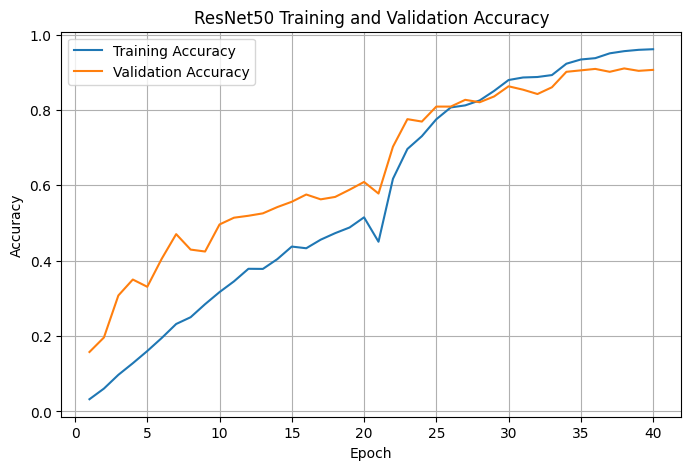

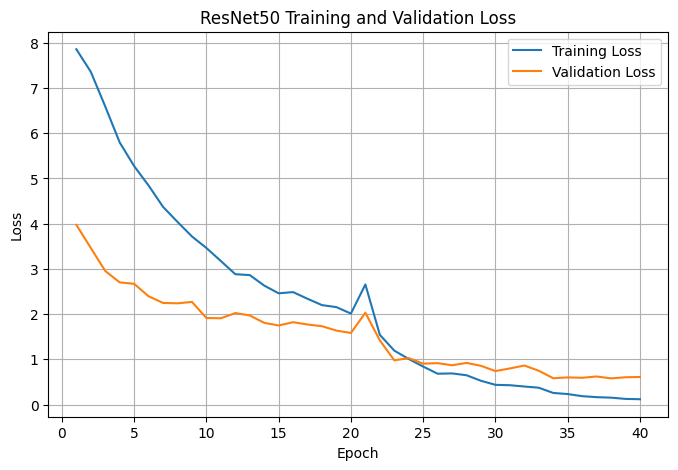

In [ ]:
res_acc = history_res_stage1.history['accuracy'] + history_res_stage2.history['accuracy']
res_val_acc = history_res_stage1.history['val_accuracy'] + history_res_stage2.history['val_accuracy']

res_loss = history_res_stage1.history['loss'] + history_res_stage2.history['loss']
res_val_loss = history_res_stage1.history['val_loss'] + history_res_stage2.history['val_loss']

res_epochs = range(1, len(res_acc) + 1)

plt.figure(figsize=(8, 5))
plt.plot(res_epochs, res_acc, label='Training Accuracy')
plt.plot(res_epochs, res_val_acc, label='Validation Accuracy')
plt.title('ResNet50 Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(res_epochs, res_loss, label='Training Loss')
plt.plot(res_epochs, res_val_loss, label='Validation Loss')
plt.title('ResNet50 Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


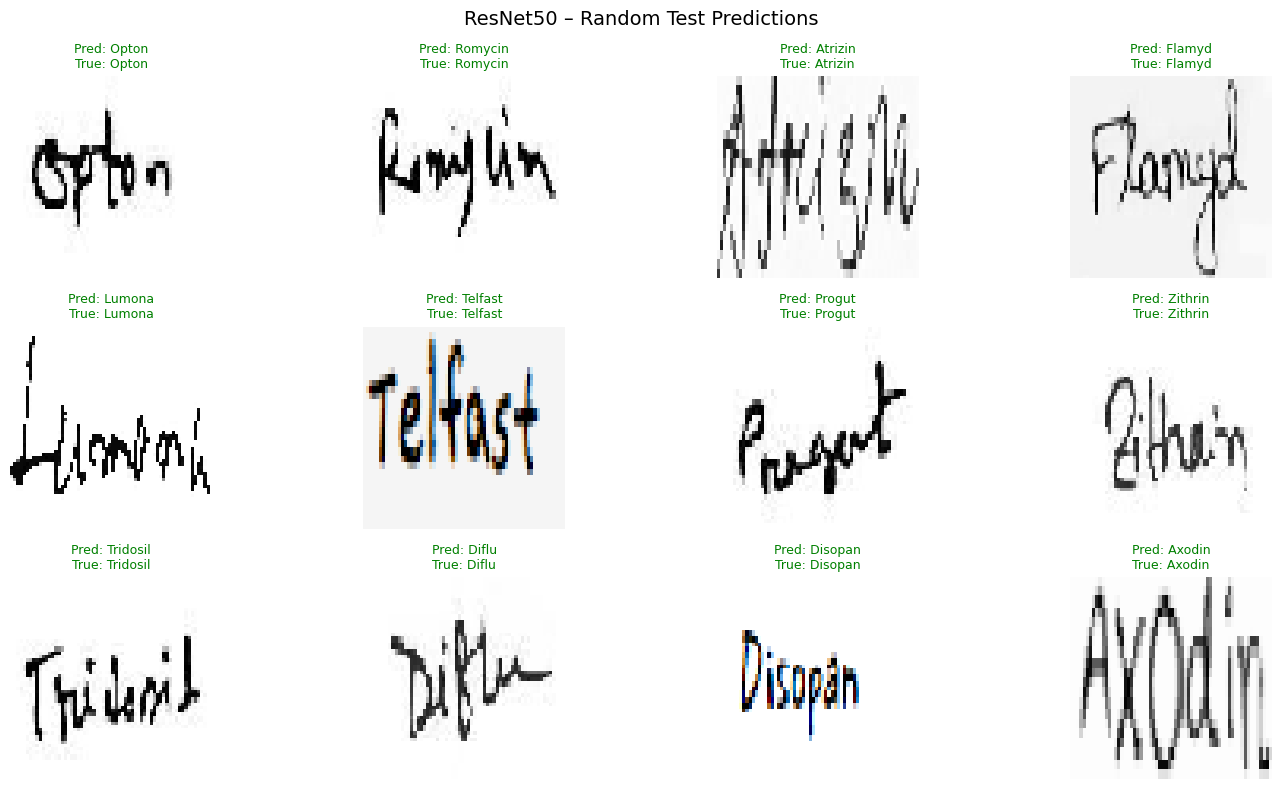

In [ ]:
show_random_predictions_auto(
    model=res_model,
    X_test_raw=X_test,
    y_test=y_test,
    label_encoder=label_encoder,
    title="ResNet50 – Random Test Predictions",
    preprocess="res"
)

## Quantitative Results

The tables below summarize the performance of each model on the test set.

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support, confusion_matrix

from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

def prep_for_model(X_raw_01, model_type, target_size=None):
    X = X_raw_01

    if target_size is not None:
        X = tf.image.resize(X, target_size).numpy()

    if model_type == "cnn":
        return X
    elif model_type == "eff":
        return eff_preprocess(X * 255.0)
    elif model_type == "res":
        return resnet_preprocess(X * 255.0)
    else:
        raise ValueError("model_type must be one of: cnn, eff, res")


def evaluate_model(model, X_raw_01, y_onehot, label_encoder, model_type, name=""):
    _, H, W, _ = model.input_shape
    X_in = prep_for_model(X_raw_01, model_type=model_type, target_size=(H, W))

    loss, acc = model.evaluate(X_in, y_onehot, verbose=0)

    probs = model.predict(X_in, verbose=0)
    y_true = np.argmax(y_onehot, axis=1)
    y_pred = np.argmax(probs, axis=1)

    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )

    return {
        "Model": name,
        "Input": f"{H}x{W}",
        "Test Loss": float(loss),
        "Test Acc": float(acc),
        "Macro Precision": float(prec),
        "Macro Recall": float(rec),
        "Macro F1": float(f1),
        "y_true": y_true,
        "y_pred": y_pred,
        "classes": label_encoder.classes_
    }

In [ ]:
from sklearn.metrics import classification_report

for r in results:
    print("\n" + "="*60)
    print(r["Model"])
    print("="*60)
    print(classification_report(
        r["y_true"],
        r["y_pred"],
        target_names=r["classes"],
        zero_division=0
    ))


CNN
              precision    recall  f1-score   support

         Ace       0.75      0.90      0.82        10
       Aceta       0.88      0.70      0.78        10
     Alatrol       0.83      0.50      0.62        10
      Amodis       0.91      1.00      0.95        10
     Atrizin       0.47      0.70      0.56        10
      Axodin       0.60      0.30      0.40        10
          Az       1.00      0.90      0.95        10
  Azithrocin       0.71      1.00      0.83        10
       Azyth       0.88      0.70      0.78        10
      Bacaid       0.77      1.00      0.87        10
    Backtone       0.56      0.50      0.53        10
    Baclofen       0.64      0.90      0.75        10
      Baclon       0.83      0.50      0.62        10
      Bacmax       1.00      0.70      0.82        10
       Beklo       0.57      0.40      0.47        10
     Bicozin       0.38      0.60      0.46        10
    Canazole       0.80      0.40      0.53        10
    Candinil       0.5

In [ ]:
import pandas as pd

cnn_best = tf.keras.models.load_model("cnn_best.keras")
eff_best = tf.keras.models.load_model("efficientnet_b0_best.keras")
res_best = tf.keras.models.load_model("resnet50_best.keras")

results = []
results.append(evaluate_model(cnn_best, X_test, y_test, label_encoder, model_type="cnn", name="CNN"))
results.append(evaluate_model(eff_best, X_test, y_test, label_encoder, model_type="eff", name="EfficientNetB0"))
results.append(evaluate_model(res_best, X_test, y_test, label_encoder, model_type="res", name="ResNet50"))

df = pd.DataFrame([{
    "Model": r["Model"],
    "Input": r["Input"],
    "Test Loss": round(r["Test Loss"], 4),
    "Test Acc (%)": round(r["Test Acc"] * 100, 2),
    "Macro Precision": round(r["Macro Precision"], 4),
    "Macro Recall": round(r["Macro Recall"], 4),
    "Macro F1": round(r["Macro F1"], 4),
} for r in results])

df = df.sort_values("Test Acc (%)", ascending=False)
print(df.to_string(index=False))

         Model   Input  Test Loss  Test Acc (%)  Macro Precision  Macro Recall  Macro F1
      ResNet50 224x224     1.8465         77.44           0.8043        0.7744    0.7679
EfficientNetB0 224x224     1.4876         69.62           0.7530        0.6962    0.6937
           CNN   64x64    11.7932         63.85           0.7081        0.6385    0.6427
